# Temel Bileşen Analizi ile Öznitelik Çıkarma

## PCA Nedir?
- PCA, yüksek boyutlu veriyi daha az boyutlu bir uzaya indirgeme tekniğidir.
- "Boyut indirgeme" yaparken en fazla bilgiyi korumayı hedefler.
- Verideki değişkenler arasındaki ilişkileri ortaya çıkarır.
- Amaç: karmaşık veriyi özetleyip, görselleştirmeyi ve öğrenmeyi kolaylaştırmak

## PCA Nasıl Çalışır?
- Verideki en fazla varyansı açıklayan doğrultuları bulur.
- Bu doğrultular "temel bileşenler (principal components) " olarak adlandırılır.
- Her bileşen, verinin yeni bir ekseni olur.
- Bileşenler birbirinden bağımsızdır.

## PCA Uygulama Adımları
- Veriyi standardize et (ortalama = 0, varyans = 1).
- Koveryans matrisini oluştur.
- Koveryans matrisinin özdeğer ve özvektörlerini hesapla.
- En yüksek özdeğere sahip bileşenleri seç.
- Veriyi bu yeni bileşenlere projekte et.

## PCA'nın Avantajları ve Sınırlılıkları
- Avantajlar:
  - Boyutu azaltır, hesaplama maliyetini düşürür.
  - Gürültüyü azaltır ve veriyi sadeleştirir.
  - Görselleştirmeyi kolaylaştırır.
  - Modelin aşırı öğrenmesini (overfitting) önlemeye yardımcı olur.
- Sınırlılıklar:
  - Yorumu zordur, bileşenler orijinal değişkenlerle doğrudan ilişkilendirilemez.
  - Doğrusal ilişkileri temel alır (non-linear yapılar için uygun değildir)
  - Ölçek farklarına duyarlıdır, her zaman standardizasyon gerekir.

## PCA Nerelerde Kullanılır?
- Görüntü sıkıştırma ve öznitelik indirgeme (ör. yüz tanıma)
- Gürültü azaltma (noise reduction)
- Veriyi 2D/3D uzayda görselleştirme
- Makine öğrenmesi modelleri öncesinde boyut azaltma
- Anomali tespiti ve sinyal işleme uygulamaları

# Principle Component Analysis - PCA (Temel Bileşen Analizi)

## PCA ile 2 ve 3 boyutlu görselleştirme yapmak
- iris veri seti kullanarak PCA ile veri boyutunu 4'ten 2'ye indirgeme yapılacaktır.
- iris veri setinde bulunan sınıfları 2 boyutlu uzayda görselleştirelim

Veri seti tanımlama:
- 150 sample, 4 features (sepal length, sepal width, petal length, petal width), 3 tane sınıf ( setosa, versicolor, virginica)
- sklearn.datasets iris veri seti modulu

Akış şeması:
1. iris veri setini yükleme
2. özellik (x) ve hedef (y) değişlenlerinin tanımlanması
3. PCA ile boyut indirgeme yapmak 4 -> 2
4. 2 boyutlu PCA sonucunu görselleştirmek

In [1]:
# gerekli olan kütüphanelerin içeri aktarılması
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# 1. iris veri setini yüklemek
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [8]:
# 2. x ve y değişkenlerinin tanımlanması
X = iris.data # features
y = iris.target #hedef değişken


In [6]:
# PCA ile dimension reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

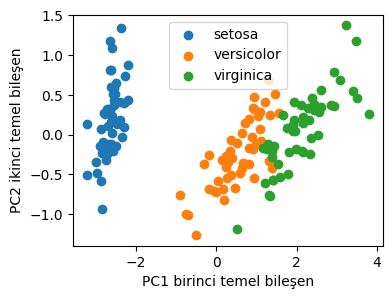

In [10]:
# 4. 2 boyutlu PCA görselleştirme
plt.figure(figsize= (4,3))
for i in range(len(iris.target_names)):
  plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label = iris.target_names[i])
plt.xlabel("PC1 birinci temel bileşen")
plt.ylabel("PC2 ikinci temel bileşen")
plt.legend()
plt.show()

In [11]:
# 3 boyutlu görselleştirme
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [12]:
iris = load_iris()
X = iris.data
y = iris.target

In [13]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

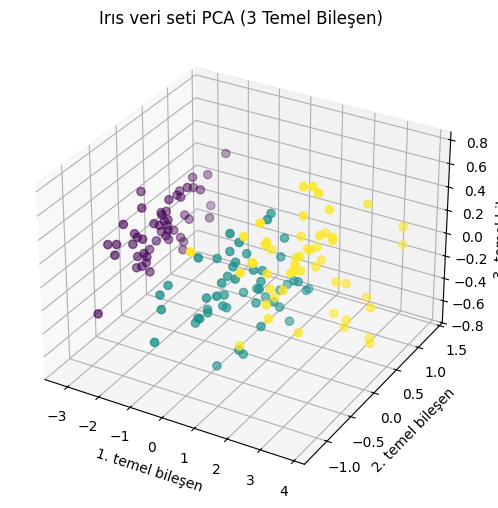

In [15]:
fig = plt.figure(1, figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=y,s=35)
ax.set_title("Irıs veri seti PCA (3 Temel Bileşen)")
ax.set_xlabel("1. temel bileşen")
ax.set_ylabel("2. temel bileşen")
ax.set_zlabel("3. temel bileşen")
plt.show()